# EDA

## Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

from scipy.stats import pearsonr
from dotenv import load_dotenv

# Custom modules
# Obtener el directorio del notebook (notebooks/)
notebook_dir = os.getcwd()
# Subir un nivel para llegar a la raíz del proyecto
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
# Agregar al path si no está (solo afecta a la instancia actual)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.data_management import get_categorical_number_columns, delete_columns

# Cargar las del archivo .env (si existe)
load_dotenv()

True

## Cargar dataset

In [2]:
#se utiliza el metodo os.path.join para construir la ruta al archivo para que sea compatible con diferentes sistemas operativos
file_raw = os.path.join('..','data', 'raw',os.getenv('FILE_RAW'))
df = pd.read_csv(file_raw)

## EDA (Basico)

### visualizacion de las primeras filas del dataset

In [ ]:
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### visualizacion de las última filas del dataset

In [ ]:
df.tail()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [7]:
# Dimension y tipos de datos del dataset
print('\nDimension:', df.shape)
print('\nTipos de datos:')
print(df.dtypes)


Dimension: (1470, 35)

Tipos de datos:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLeve

Por defecto la libreria pandas si encuentra valores numericos en una variable los interpreta como numericos, como sabemos que algunos numericos son categoricos, para proceder de una forma mas eficiente en la exploración se convierten a categoricos antes de continuar con el analisis.

In [8]:
# Convertir columnas numéricas categóricas a tipo 'object'
categoricas_numericas = get_categorical_number_columns()

for col in categoricas_numericas:
    if col in df.columns:
        df[col] = df[col].astype("object")

In [ ]:
# ============================================================================
# ANÁLISIS DE VALORES NULOS
# ============================================================================

print("=" * 80)
print("ANÁLISIS DE VALORES NULOS")
print("=" * 80)

# Contar nulos
null_counts = df.isnull().sum()
columns_with_nulls = null_counts[null_counts > 0]

if len(columns_with_nulls) > 0:
    print(f"\n⚠️  Columnas con valores nulos: {len(columns_with_nulls)}\n")
    
    for col in columns_with_nulls.index:
        count = null_counts[col]
        percentage = (count / len(df)) * 100
        print(f"   ❌ {col:30s}: {count:5d} nulos ({percentage:5.2f}%)")
    
    print(f"\n📊 Total nulos: {null_counts.sum()} de {len(df) * len(df.columns)} valores")
else:
    print("\n✅ No existen valores nulos en el dataset")
    print(f"📊 Dataset completo: {len(df)} filas × {len(df.columns)} columnas")

print("=" * 80)

ANÁLISIS DE VALORES NULOS

✅ No existen valores nulos en el dataset
📊 Dataset completo: 1470 filas × 35 columnas


In [10]:
# Estadísticas descriptivas
df.describe()

,Age,DailyRate,DistanceFromHome,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobLevel,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,1.0,1024.865306,2.721769,65.891156,2.063946,6502.931293,14313.103401,2.693197,15.209524,80.0,0.793878,11.279592,2.799320,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,0.0,602.024335,1.093082,20.329428,1.106940,4707.956783,7117.786044,2.498009,3.659938,0.0,0.852077,7.780782,1.289271,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,80.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,1.0,491.250000,2.000000,48.000000,1.000000,2911.000000,8047.000000,1.000000,12.000000,80.0,0.000000,6.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,1.0,1020.500000,3.000000,66.000000,2.000000,4919.000000,14235.500000,2.000000,14.000000,80.0,1.000000,10.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,1.0,1555.750000,4.000000,83.750000,3.000000,8379.000000,20461.500000,4.000000,18.000000,80.0,1.000000,15.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,1.0,2068.000000,4.000000,100.000000,5.000000,19999.000000,26999.000000,9.000000,25.000000,80.0,3.000000,40.000000,6.000000,40.000000,18.000000,15.000000,17.000000


### Analisis de Variables

In [ ]:
"""
ANÁLISIS DE VARIABLES PARA ELIMINACIÓN
==========================================================
Este código NO elimina variables, solo las identifica y explica POR QUÉ deberían eliminarse.
"""

# ============================================================================
# CONFIGURACIÓN
# ============================================================================
TARGET = 'MonthlyIncome'

print("=" * 100)
print("ANÁLISIS DE VARIABLES PARA ELIMINACIÓN")
print("=" * 100)
print(f"\nDataset: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Variable objetivo: {TARGET}\n")


# ============================================================================
# LISTA DE VARIABLES A EXCLUIR DE ANÁLISIS POSTERIORES
# ============================================================================
variables_ya_identificadas = []  # ← CLAVE: Lista para evitar duplicados

# ============================================================================
# 1. DETECCIÓN DE VARIABLES CONSTANTES
# ============================================================================
print("\n" + "=" * 100)
print("1. VARIABLES CONSTANTES (Sin varianza)")
print("=" * 100)
print("\nEstas variables tienen UN SOLO valor para todos los registros.\n")

constant_vars = []
for col in df.columns:
    if col == TARGET:  # No analizar la variable objetivo
        continue
        
    if df[col].nunique() == 1:
        value = df[col].iloc[0]
        constant_vars.append({
            'Variable': col,
            'Valor_Constante': value,
            'Motivo_Eliminacion': 'Varianza = 0, no aporta información'
        })
        variables_ya_identificadas.append(col)  # ← Agregar a la lista de exclusión
        
        print(f"❌ {col:30s} = {value}")
        print(f"   └─ Razón: Todos los registros tienen el mismo valor")
        print(f"   └─ Impacto: No puede diferenciar entre salarios altos/bajos")
        print()

if len(constant_vars) == 0:
    print("✅ No se encontraron variables constantes\n")
else:
    print(f"📊 Total: {len(constant_vars)} variables constantes\n")

# ============================================================================
# 2. DETECCIÓN DE IDENTIFICADORES ÚNICOS
# ============================================================================
print("\n" + "=" * 100)
print("2. IDENTIFICADORES ÚNICOS (Una ID por registro)")
print("=" * 100)
print("\nEstas variables tienen un valor diferente para cada registro.\n")

identifier_vars = []
for col in df.columns:
    if col == TARGET:  # No analizar la variable objetivo
        continue
    
    if col in variables_ya_identificadas:  # ← Saltar si ya fue identificada
        continue
        
    if df[col].nunique() == len(df):
        identifier_vars.append({
            'Variable': col,
            'Valores_Unicos': df[col].nunique(),
            'Motivo_Eliminacion': 'Identificador único, no tiene poder predictivo'
        })
        variables_ya_identificadas.append(col)  # ← Agregar a la lista de exclusión
        
        print(f"❌ {col:30s}")
        print(f"   └─ Razón: {df[col].nunique()} valores únicos en {len(df)} registros")
        print(f"   └─ Impacto: Es solo un ID, no predice el salario")
        print()

if len(identifier_vars) == 0:
    print("✅ No se encontraron identificadores únicos\n")
else:
    print(f"📊 Total: {len(identifier_vars)} identificadores\n")

# ============================================================================
# 3. CORRELACIÓN CON VARIABLE OBJETIVO (Variables Irrelevantes)
# ============================================================================
print("\n" + "=" * 100)
print("3. CORRELACIÓN CON VARIABLE OBJETIVO")
print("=" * 100)
print(f"\nEstas variables tienen correlación muy baja con {TARGET}.\n")

# Obtener solo columnas numéricas que NO han sido identificadas previamente
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# ← CLAVE: Filtrar variables ya identificadas y el objetivo
numeric_cols = [col for col in numeric_cols 
                if col not in variables_ya_identificadas and col != TARGET]

print(f"Variables numéricas a analizar: {len(numeric_cols)}")
print(f"(Excluidas {len(variables_ya_identificadas)} ya identificadas como constantes/ID)\n")

correlations = []
for col in numeric_cols:
    try:
        corr, p_value = pearsonr(df[col].dropna(), df[TARGET].dropna())
        correlations.append({
            'Variable': col,
            'Correlacion': corr,
            'Correlacion_Abs': abs(corr),
            'P_value': p_value
        })
    except Exception as e:
        print(f"⚠️  No se pudo calcular correlación para {col}: {e}")

if len(correlations) == 0:
    print("⚠️  No hay variables numéricas para analizar correlación\n")
else:
    corr_df = pd.DataFrame(correlations).sort_values('Correlacion_Abs', ascending=False)
    
    # Clasificar por nivel de correlación
    print("Clasificación por correlación con MonthlyIncome:")
    print("-" * 100)
    
    # Variables con correlación ALTA (>0.3)
    high_corr = corr_df[corr_df['Correlacion_Abs'] > 0.3]
    print(f"\n✅ MANTENER - Correlación ALTA (|r| > 0.3): {len(high_corr)} variables")
    print("-" * 100)
    for _, row in high_corr.iterrows():
        print(f"   ✓ {row['Variable']:30s}: {row['Correlacion']:7.4f}")
    
    # Variables con correlación MODERADA (0.1 - 0.3)
    moderate_corr = corr_df[(corr_df['Correlacion_Abs'] >= 0.1) & (corr_df['Correlacion_Abs'] <= 0.3)]
    print(f"\n⚠️  REVISAR - Correlación MODERADA (0.1 ≤ |r| ≤ 0.3): {len(moderate_corr)} variables")
    print("-" * 100)
    for _, row in moderate_corr.iterrows():
        print(f"   ⚠️ {row['Variable']:30s}: {row['Correlacion']:7.4f}")
        print(f"      └─ Motivo: Correlación baja-moderada, puede no aportar mucho")
    
    # Variables con correlación BAJA (<0.1)
    low_corr = corr_df[corr_df['Correlacion_Abs'] < 0.1]
    print(f"\n❌ ELIMINAR - Correlación BAJA (|r| < 0.1): {len(low_corr)} variables")
    print("-" * 100)
    low_corr_vars = []
    for _, row in low_corr.iterrows():
        low_corr_vars.append({
            'Variable': row['Variable'],
            'Correlacion': row['Correlacion'],
            'Motivo_Eliminacion': f'Correlación muy baja ({row["Correlacion"]:.4f}), no predice el salario'
        })
        variables_ya_identificadas.append(row['Variable'])  # ← Agregar a la lista de exclusión
        
        print(f"   ❌ {row['Variable']:30s}: {row['Correlacion']:7.4f}")
        print(f"      └─ Razón: Correlación prácticamente nula con {TARGET}")
        print(f"      └─ Impacto: No ayuda a predecir salarios altos vs bajos")

# ============================================================================
# 4. MULTICOLINEALIDAD (Variables Redundantes)
# ============================================================================
print("\n\n" + "=" * 100)
print("4. MULTICOLINEALIDAD - VARIABLES REDUNDANTES")
print("=" * 100)
print("\nEstas variables están MUY correlacionadas entre sí (redundantes).\n")

# ← CLAVE: Usar solo variables que NO han sido identificadas para eliminar
numeric_cols_for_multicollinearity = [col for col in numeric_cols 
                                      if col not in [v['Variable'] for v in low_corr_vars]]

if len(numeric_cols_for_multicollinearity) < 2:
    print("⚠️  No hay suficientes variables para analizar multicolinealidad\n")
else:
    # Calcular matriz de correlación
    corr_matrix = df[numeric_cols_for_multicollinearity].corr()
    
    # Encontrar pares con alta correlación
    multicollinearity_vars = []
    high_corr_pairs = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            var1 = corr_matrix.columns[i]
            var2 = corr_matrix.columns[j]
            corr_value = corr_matrix.iloc[i, j]
            
            if abs(corr_value) > 0.7:  # Umbral de multicolinealidad
                # Obtener correlación de cada variable con el objetivo
                try:
                    corr_var1_target = df[[var1, TARGET]].corr().iloc[0, 1]
                    corr_var2_target = df[[var2, TARGET]].corr().iloc[0, 1]
                    
                    # Decidir cuál eliminar (la de menor correlación con objetivo)
                    if abs(corr_var1_target) < abs(corr_var2_target):
                        var_to_remove = var1
                        var_to_keep = var2
                    else:
                        var_to_remove = var2
                        var_to_keep = var1
                    
                    high_corr_pairs.append({
                        'Variable_1': var1,
                        'Variable_2': var2,
                        'Correlacion_Entre_Ellas': corr_value,
                        'Corr_Var1_Target': corr_var1_target,
                        'Corr_Var2_Target': corr_var2_target,
                        'Eliminar': var_to_remove,
                        'Mantener': var_to_keep
                    })
                except Exception as e:
                    print(f"⚠️  Error al calcular correlación con objetivo para {var1}, {var2}: {e}")
    
    if len(high_corr_pairs) > 0:
        print(f"Se encontraron {len(high_corr_pairs)} pares con correlación > 0.7:\n")
        
        for pair in high_corr_pairs:
            print(f"Par: {pair['Variable_1']} ↔ {pair['Variable_2']}")
            print(f"   Correlación entre ellas: {pair['Correlacion_Entre_Ellas']:.4f}")
            print(f"   Correlación {pair['Variable_1']} → {TARGET}: {pair['Corr_Var1_Target']:.4f}")
            print(f"   Correlación {pair['Variable_2']} → {TARGET}: {pair['Corr_Var2_Target']:.4f}")
            print(f"   ❌ ELIMINAR: {pair['Eliminar']}")
            print(f"   ✅ MANTENER: {pair['Mantener']}")
            print(f"   └─ Razón: Ambas miden prácticamente lo mismo, mantener solo la más predictiva")
            print()
            
            # Agregar a lista de variables a eliminar (evitando duplicados)
            if pair['Eliminar'] not in [v['Variable'] for v in multicollinearity_vars]:
                multicollinearity_vars.append({
                    'Variable': pair['Eliminar'],
                    'Correlacionada_Con': pair['Mantener'],
                    'Correlacion': pair['Correlacion_Entre_Ellas'],
                    'Motivo_Eliminacion': f"Redundante con {pair['Mantener']} (corr={pair['Correlacion_Entre_Ellas']:.2f})"
                })
                variables_ya_identificadas.append(pair['Eliminar'])  # ← Agregar a la lista de exclusión
    else:
        print("✅ No se encontró multicolinealidad severa (todas las correlaciones < 0.7)\n")

# ============================================================================
# 5. ANÁLISIS DE VARIABLES CATEGÓRICAS
# ============================================================================
print("\n" + "=" * 100)
print("5. ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("=" * 100)
print(f"\nVariación del {TARGET} según cada variable categórica.\n")

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# ← CLAVE: Filtrar variables ya identificadas
categorical_cols = [col for col in categorical_cols 
                    if col not in variables_ya_identificadas and col != TARGET]

if len(categorical_cols) == 0:
    print("⚠️  No hay variables categóricas para analizar\n")
else:
    for col in categorical_cols:
        print(f"\n{col}:")
        print("-" * 80)
        
        # Calcular estadísticas por categoría
        grouped = df.groupby(col)[TARGET].agg(['mean', 'std', 'count'])
        print(grouped)
        
        # Calcular variación entre categorías
        overall_mean = df[TARGET].mean()
        category_means = grouped['mean']
        variation = category_means.std() / overall_mean
        
        print(f"\nVariación entre categorías: {variation:.2%}")
        
        if variation < 0.1:
            print(f"⚠️  CONSIDERAR ELIMINAR: Muy poca variación en salarios entre categorías")
        else:
            print(f"✅ MANTENER: Hay diferencias significativas en salarios entre categorías")

# ============================================================================
# 6. RESUMEN Y RECOMENDACIONES
# ============================================================================
print("\n\n" + "=" * 100)
print("RESUMEN DE VARIABLES A ELIMINAR")
print("=" * 100)

# Consolidar todas las variables a eliminar
all_vars_to_remove = []

# Variables constantes
for var in constant_vars:
    all_vars_to_remove.append(var)

# Identificadores
for var in identifier_vars:
    all_vars_to_remove.append(var)

# Baja correlación
for var in low_corr_vars:
    all_vars_to_remove.append(var)

# Multicolinealidad
for var in multicollinearity_vars:
    all_vars_to_remove.append(var)

# Crear DataFrame resumen
if len(all_vars_to_remove) > 0:
    summary_df = pd.DataFrame(all_vars_to_remove)
    
    print(f"\n📊 Total de variables recomendadas para eliminar: {len(all_vars_to_remove)}")
    print(f"📊 Porcentaje del dataset: {len(all_vars_to_remove)/(len(df.columns)-1)*100:.1f}%")
    print(f"   (Excluyendo variable objetivo {TARGET})\n")
    
    # Mostrar por categoría
    print("\nDETALLE POR CATEGORÍA:")
    print("=" * 100)
    
    if len(constant_vars) > 0:
        print(f"\n1. Variables CONSTANTES ({len(constant_vars)}):")
        for var in constant_vars:
            print(f"   ❌ {var['Variable']:30s} → {var['Motivo_Eliminacion']}")
    
    if len(identifier_vars) > 0:
        print(f"\n2. IDENTIFICADORES únicos ({len(identifier_vars)}):")
        for var in identifier_vars:
            print(f"   ❌ {var['Variable']:30s} → {var['Motivo_Eliminacion']}")
    
    if len(low_corr_vars) > 0:
        print(f"\n3. Variables con BAJA CORRELACIÓN ({len(low_corr_vars)}):")
        for var in low_corr_vars:
            print(f"   ❌ {var['Variable']:30s} → {var['Motivo_Eliminacion']}")
    
    if len(multicollinearity_vars) > 0:
        print(f"\n4. Variables REDUNDANTES por multicolinealidad ({len(multicollinearity_vars)}):")
        for var in multicollinearity_vars:
            print(f"   ❌ {var['Variable']:30s} → {var['Motivo_Eliminacion']}")
    
    
print("\n" + "=" * 100)
print("ANÁLISIS COMPLETADO")
print("⚠️  Importante estar alineado con negocio antes de eliminar variables, que puedan ser relevantes para la toma de decisiones.")

print("=" * 100)

ANÁLISIS DE VARIABLES PARA ELIMINACIÓN

Dataset: 1470 filas, 35 columnas
Variable objetivo: MonthlyIncome


1. VARIABLES CONSTANTES (Sin varianza)

Estas variables tienen UN SOLO valor para todos los registros.

❌ EmployeeCount                  = 1
   └─ Razón: Todos los registros tienen el mismo valor
   └─ Impacto: No puede diferenciar entre salarios altos/bajos

❌ Over18                         = Y
   └─ Razón: Todos los registros tienen el mismo valor
   └─ Impacto: No puede diferenciar entre salarios altos/bajos

❌ StandardHours                  = 80
   └─ Razón: Todos los registros tienen el mismo valor
   └─ Impacto: No puede diferenciar entre salarios altos/bajos

📊 Total: 3 variables constantes


2. IDENTIFICADORES ÚNICOS (Una ID por registro)

Estas variables tienen un valor diferente para cada registro.

❌ EmployeeNumber                
   └─ Razón: 1470 valores únicos en 1470 registros
   └─ Impacto: Es solo un ID, no predice el salario

📊 Total: 1 identificadores


3. CORR



VISUALIZACIÓN: MAPA DE CALOR DE CORRELACIONES

✅ Mapa de calor guardado como 'mapa_correlaciones.png'
✅ Gráfico de correlaciones guardado como 'correlaciones_con_objetivo.png'


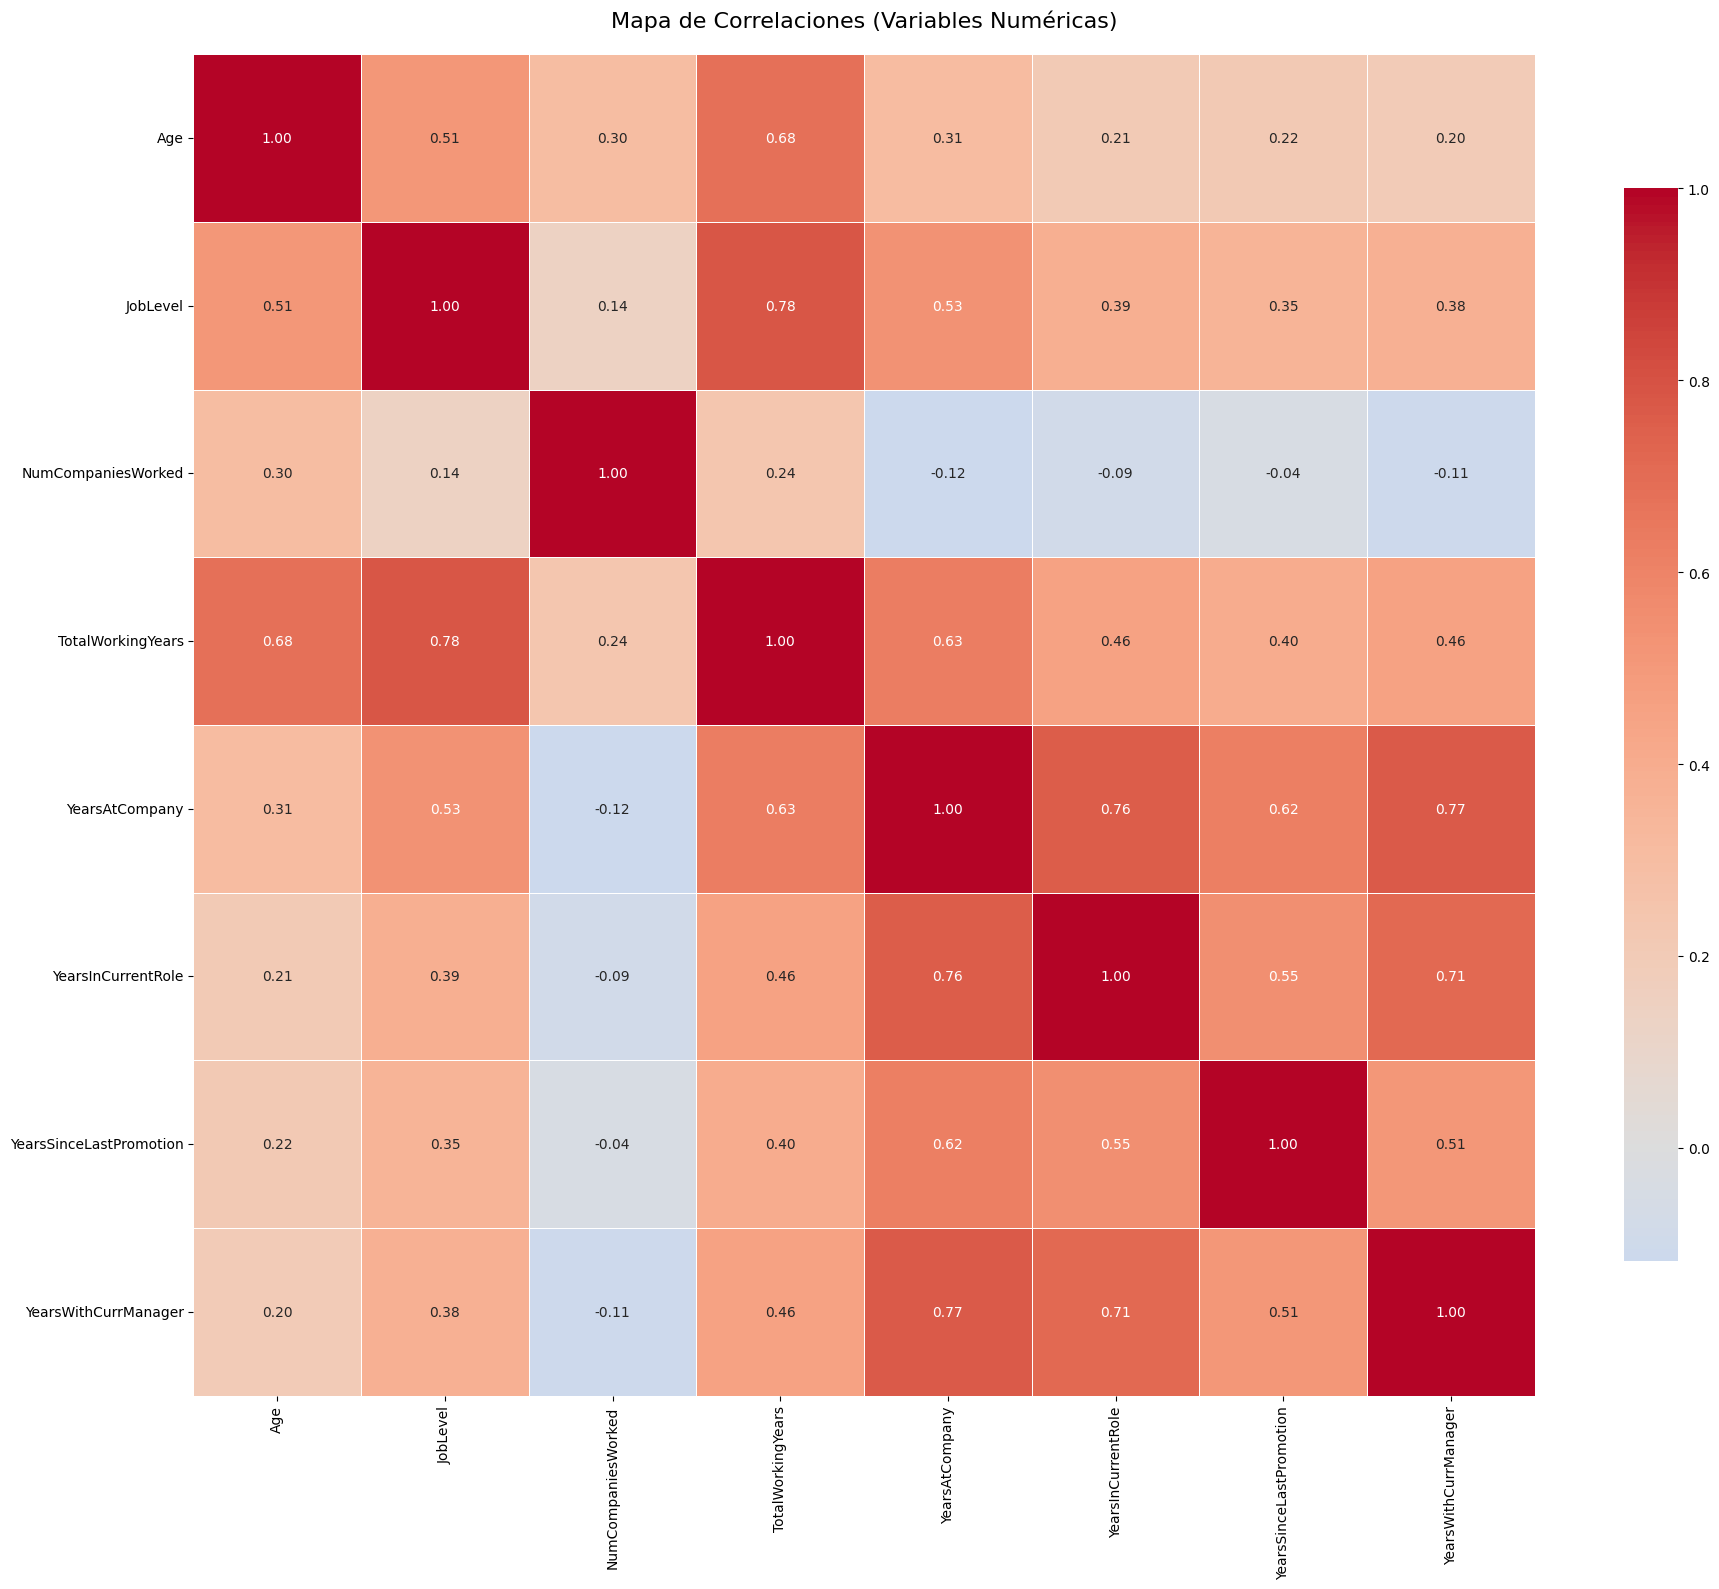

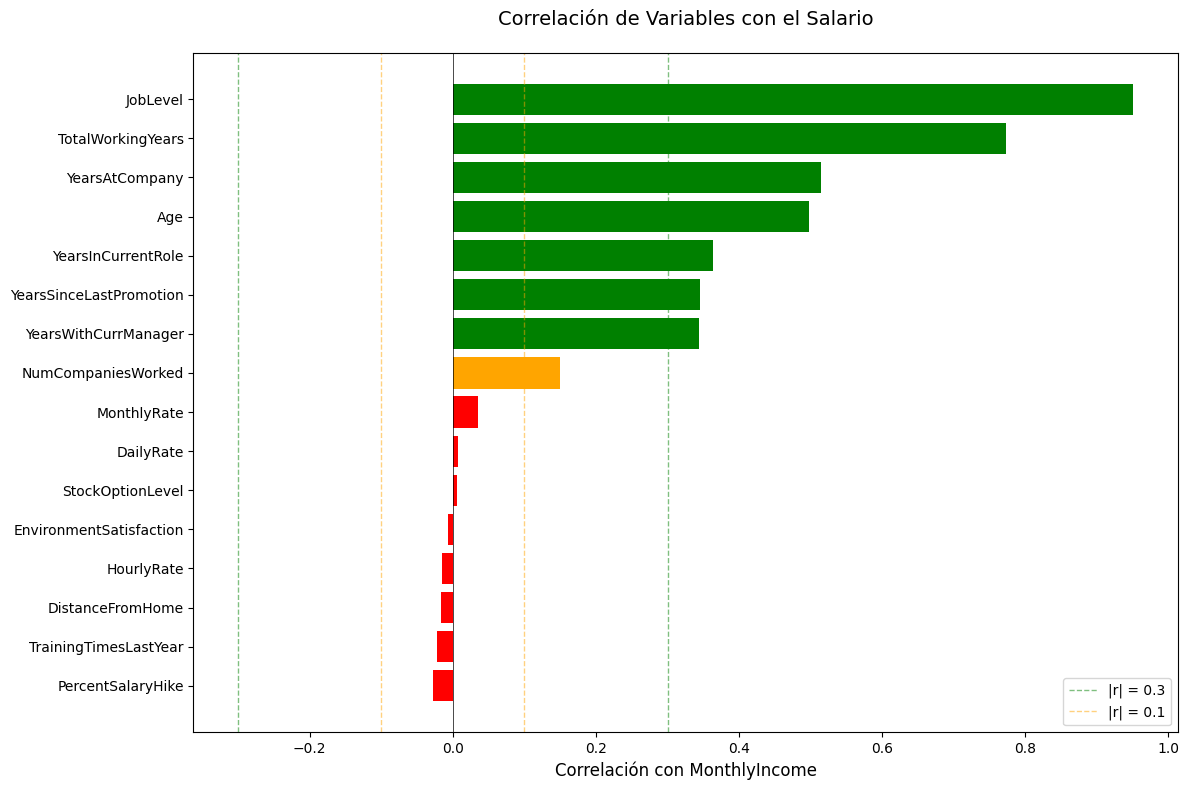



ANÁLISIS COMPLETADO

📝 Revisa los resultados y decide qué variables eliminar según tu criterio.
📊 Las visualizaciones te ayudarán a tomar decisiones informadas.
💡 Recuerda: Puedes mantener algunas variables si tienes razones de negocio.


In [21]:

# ============================================================================
# 7. VISUALIZACIÓN DEL MAPA DE CALOR
# ============================================================================
print("\n\n" + "=" * 100)
print("VISUALIZACIÓN: MAPA DE CALOR DE CORRELACIONES")
print("=" * 100)

# Crear mapa de calor
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Mapa de Correlaciones (Variables Numéricas)', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'figures', 'mapa_correlaciones.png'), dpi=300, bbox_inches='tight')
print("\n✅ Mapa de calor guardado como 'mapa_correlaciones.png'")

# Visualización de correlaciones con objetivo
plt.figure(figsize=(12, 8))
corr_with_target = corr_df.sort_values('Correlacion', ascending=True)
colors = ['red' if abs(x) < 0.1 else 'orange' if abs(x) < 0.3 else 'green' 
          for x in corr_with_target['Correlacion']]
plt.barh(corr_with_target['Variable'], corr_with_target['Correlacion'], color=colors)
plt.xlabel('Correlación con MonthlyIncome', fontsize=12)
plt.title('Correlación de Variables con el Salario', fontsize=14, pad=20)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.axvline(x=0.3, color='green', linestyle='--', linewidth=1, alpha=0.5, label='|r| = 0.3')
plt.axvline(x=-0.3, color='green', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(x=0.1, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='|r| = 0.1')
plt.axvline(x=-0.1, color='orange', linestyle='--', linewidth=1, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'figures', 'correlaciones_con_objetivo.png'), dpi=300, bbox_inches='tight')
print("✅ Gráfico de correlaciones guardado como 'correlaciones_con_objetivo.png'")

plt.show()

print("\n\n" + "=" * 100)
print("ANÁLISIS COMPLETADO")
print("=" * 100)
print("\n📝 Revisa los resultados y decide qué variables eliminar según tu criterio.")
print("📊 Las visualizaciones te ayudarán a tomar decisiones informadas.")
print("💡 Recuerda: Puedes mantener algunas variables si tienes razones de negocio.")

### Revision y justificacion de outliers

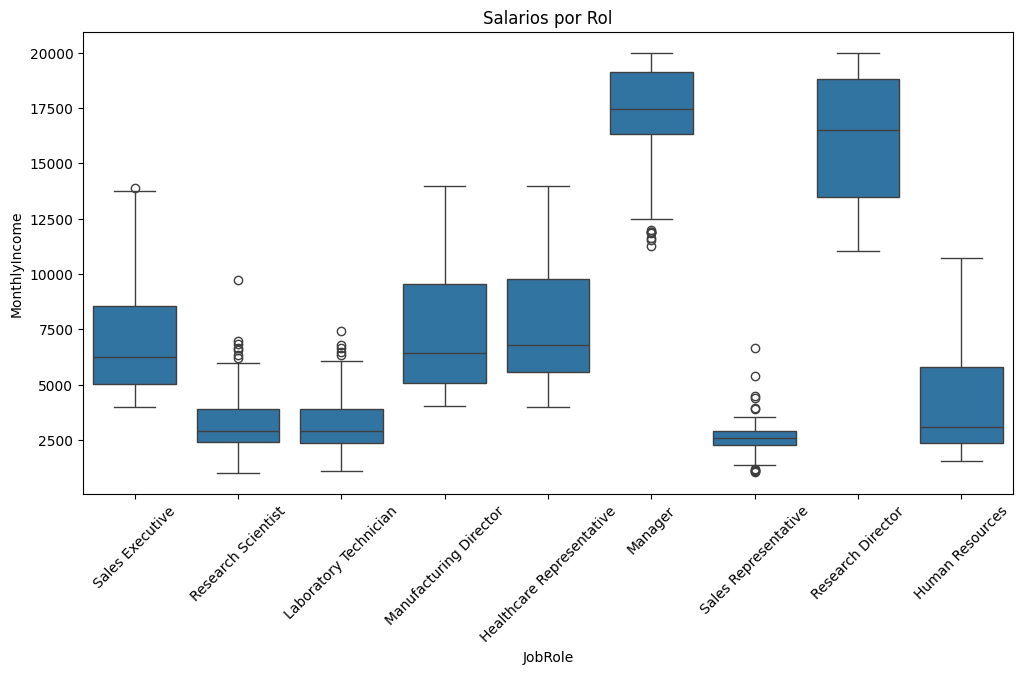

<Figure size 640x480 with 0 Axes>

In [22]:
# Ingresos por rol
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='JobRole', y='MonthlyIncome')
plt.xticks(rotation=45)
plt.title('Salarios por Rol')
plt.show()
plt.savefig(os.path.join('..', 'outputs', 'figures', 'salarios_por_rol.png'))

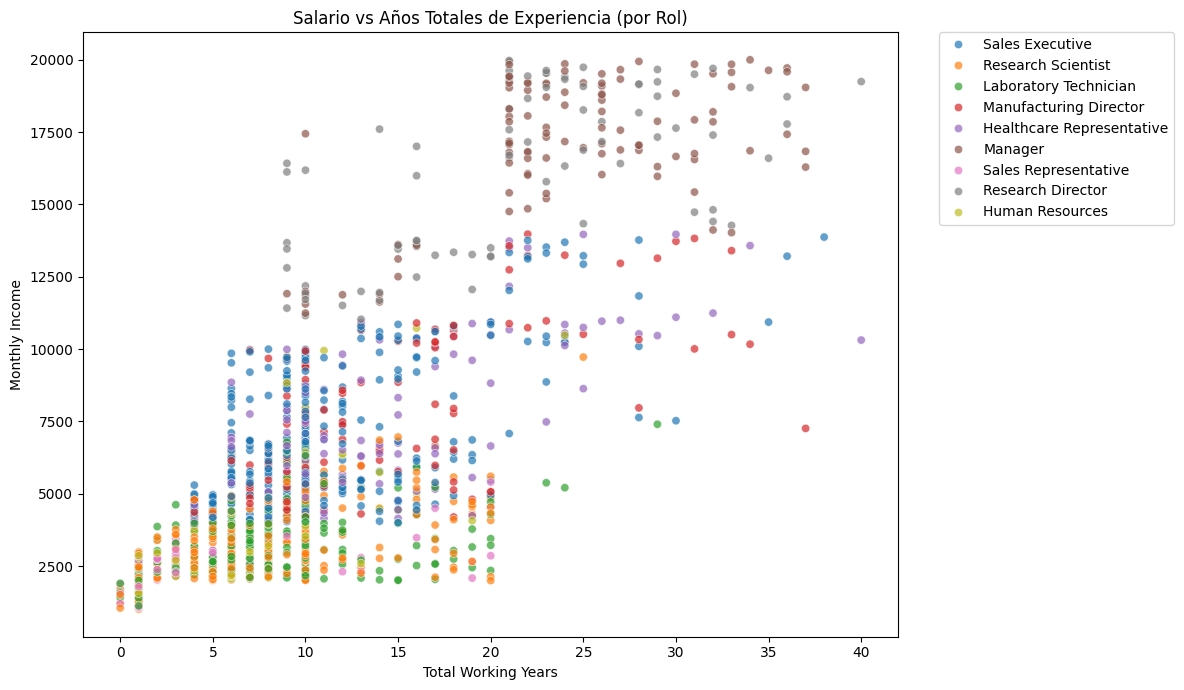

<Figure size 640x480 with 0 Axes>

In [25]:
# Relaciones clave entre salario y experiencia con color por rol
plt.figure(figsize=(12,7))
sns.scatterplot(data=df, x='TotalWorkingYears', y='MonthlyIncome', hue='JobRole', alpha=0.7)
plt.title('Salario vs Años Totales de Experiencia (por Rol)')
plt.xlabel('Total Working Years')
plt.ylabel('Monthly Income')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()
plt.savefig(os.path.join('..','outputs','figures','salario_vs_experiencia_por_rol.png'), bbox_inches='tight')

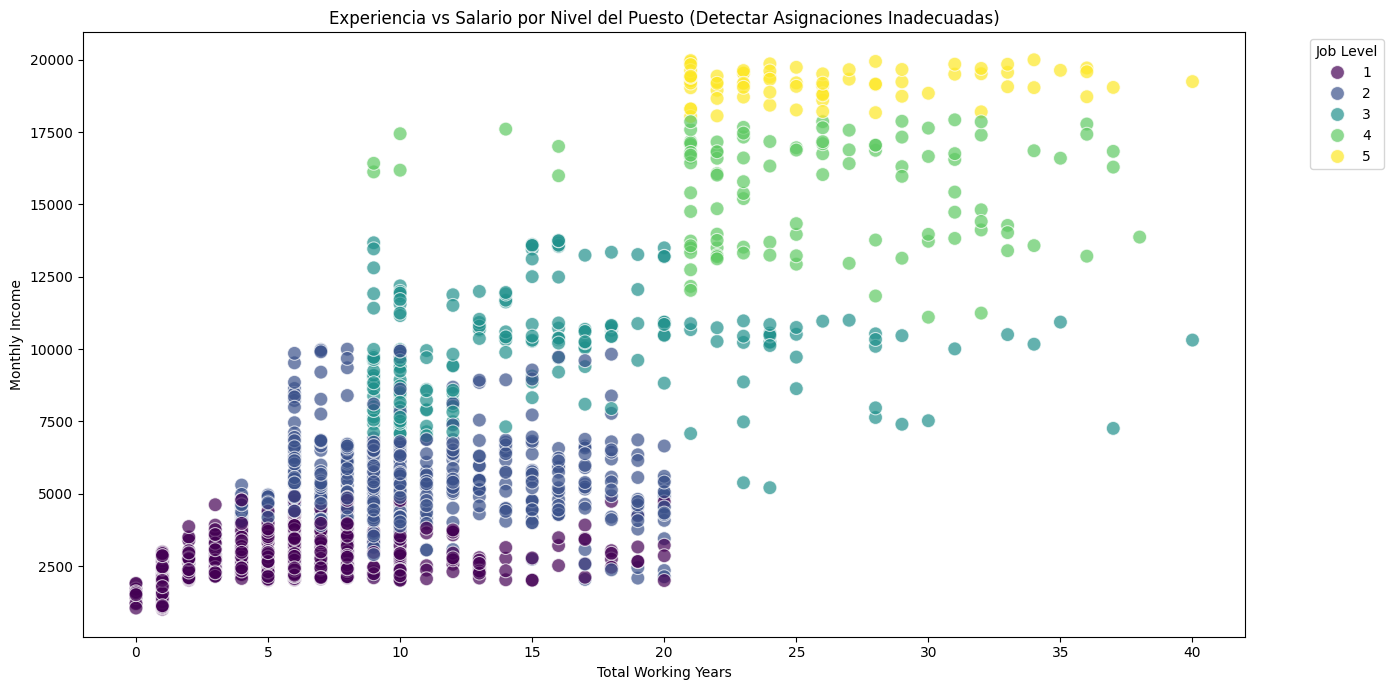

In [26]:
# 3. Experiencia vs Salario por JobLevel (detectar anomalías)
plt.figure(figsize=(14,7))
sns.scatterplot(data=df, x='TotalWorkingYears', y='MonthlyIncome', hue='JobLevel', 
                palette='viridis', s=100, alpha=0.7)
plt.title('Experiencia vs Salario por Nivel del Puesto (Detectar Asignaciones Inadecuadas)')
plt.xlabel('Total Working Years')
plt.ylabel('Monthly Income')
plt.legend(title='Job Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'figures', 'experiencia_salario_joblevel.png'), bbox_inches='tight')
plt.show()

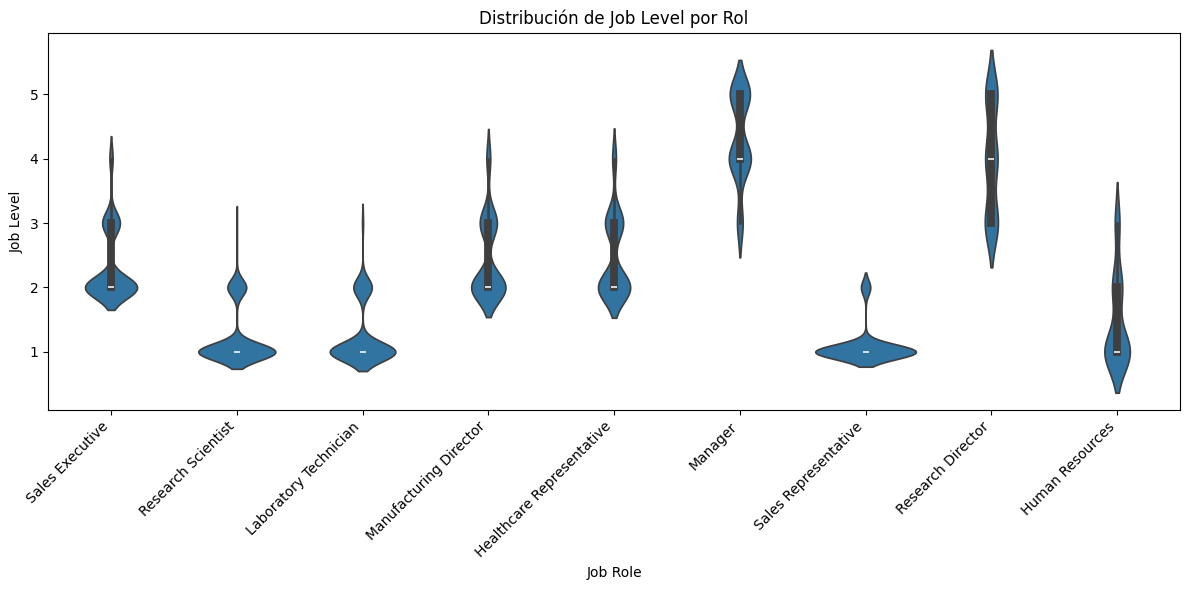

In [27]:
# Gráfico de dispersión con violín para Job Role vs Job Level
plt.figure(figsize=(12,6))
sns.violinplot(data=df, x='JobRole', y='JobLevel', inner='box')
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Job Level por Rol')
plt.xlabel('Job Role')
plt.ylabel('Job Level')
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'figures', 'joblevel_por_rol.png'), bbox_inches='tight')
plt.show()

/var/folders/fs/p7f3rv_51xndn3fmnjvzz3380000gn/T/ipykernel_91296/3405863727.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/fs/p7f3rv_51xndn3fmnjvzz3380000gn/T/ipykernel_91296/3405863727.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


✅ Gráfico guardado: ../outputs/figures/analisis_salario_rol_nivel.png


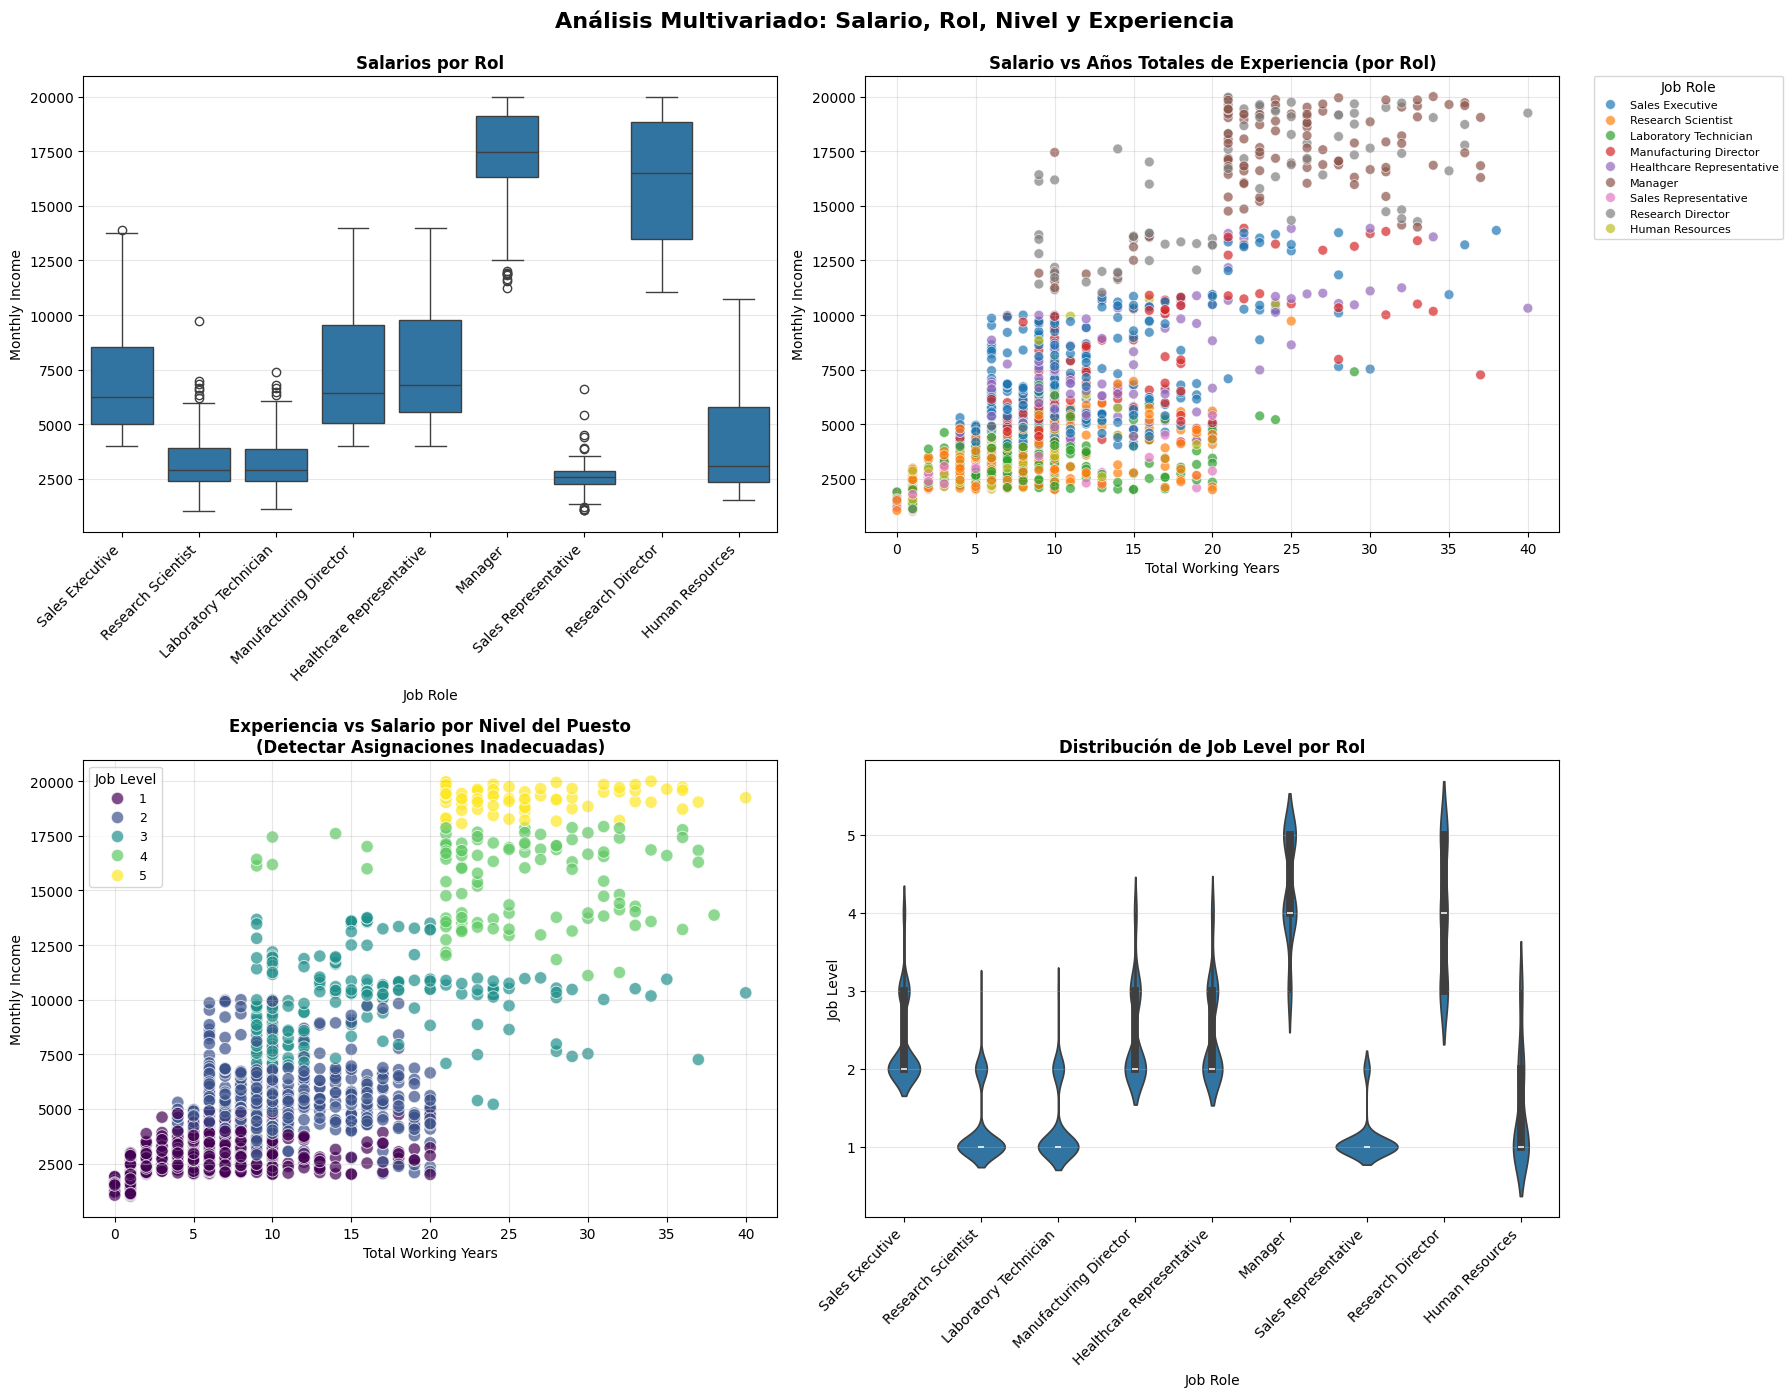

In [32]:

# ============================================
# CREAR FIGURA CON GRID 2x2
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ============================================
# GRÁFICO 1: Salarios por Rol (arriba izquierda)
# ============================================

ax = axes[0, 0]
sns.boxplot(data=df, x='JobRole', y='MonthlyIncome', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Salarios por Rol', fontsize=12, fontweight='bold')
ax.set_xlabel('Job Role', fontsize=10)
ax.set_ylabel('Monthly Income', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# ============================================
# GRÁFICO 2: Salario vs Experiencia por Rol (arriba derecha)
# ============================================

ax = axes[0, 1]
sns.scatterplot(data=df, x='TotalWorkingYears', y='MonthlyIncome', 
                hue='JobRole', alpha=0.7, ax=ax, s=50)
ax.set_title('Salario vs Años Totales de Experiencia (por Rol)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Total Working Years', fontsize=10)
ax.set_ylabel('Monthly Income', fontsize=10)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, 
          borderaxespad=0, title='Job Role')
ax.grid(True, alpha=0.3)

# ============================================
# GRÁFICO 3: Experiencia vs Salario por JobLevel (abajo izquierda)
# ============================================

ax = axes[1, 0]
sns.scatterplot(data=df, x='TotalWorkingYears', y='MonthlyIncome', 
                hue='JobLevel', palette='viridis', s=80, alpha=0.7, ax=ax)
ax.set_title('Experiencia vs Salario por Nivel del Puesto\n(Detectar Asignaciones Inadecuadas)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Total Working Years', fontsize=10)
ax.set_ylabel('Monthly Income', fontsize=10)
ax.legend(title='Job Level', fontsize=9)
ax.grid(True, alpha=0.3)

# ============================================
# GRÁFICO 4: Distribución JobLevel por Rol (abajo derecha)
# ============================================

ax = axes[1, 1]
sns.violinplot(data=df, x='JobRole', y='JobLevel', inner='box', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Distribución de Job Level por Rol', fontsize=12, fontweight='bold')
ax.set_xlabel('Job Role', fontsize=10)
ax.set_ylabel('Job Level', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# ============================================
# TÍTULO GENERAL Y AJUSTES
# ============================================

fig.suptitle('Análisis Multivariado: Salario, Rol, Nivel y Experiencia', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()

# ============================================
# GUARDAR
# ============================================

output_path = os.path.join('..', 'outputs', 'figures', 'analisis_salario_rol_nivel.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico guardado: {output_path}")

plt.show()

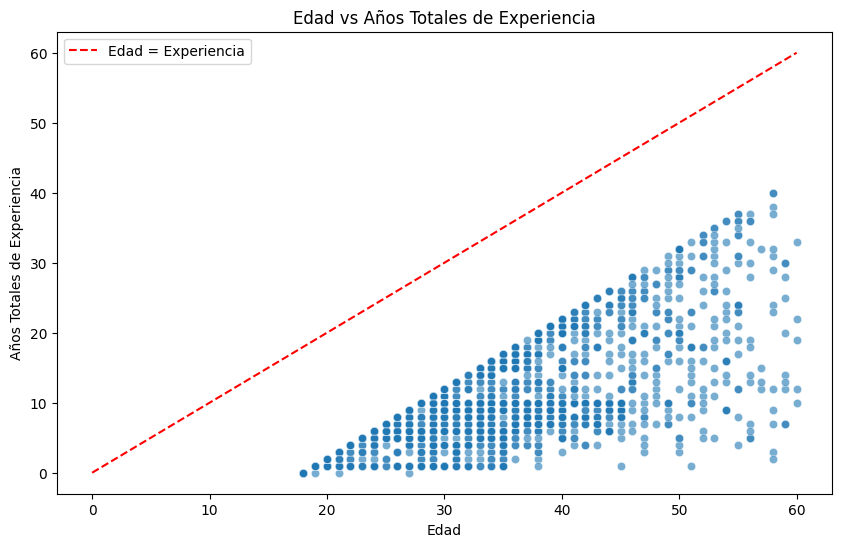

<Figure size 640x480 with 0 Axes>

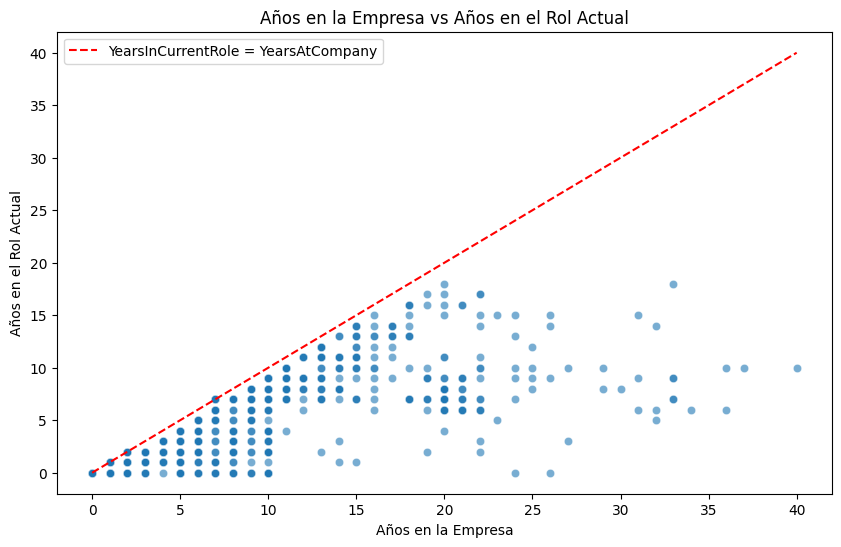

<Figure size 640x480 with 0 Axes>

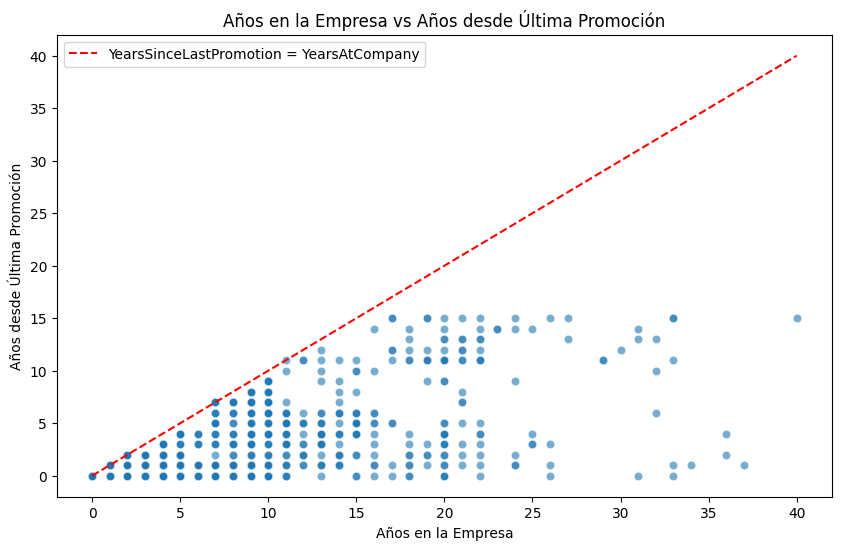

<Figure size 640x480 with 0 Axes>

In [30]:
# Análisis de consistencia: Edad vs Años de Experiencia
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='TotalWorkingYears', alpha=0.6)
plt.plot([0, df['Age'].max()], [0, df['Age'].max()], 'r--', label='Edad = Experiencia')
plt.title('Edad vs Años Totales de Experiencia')
plt.xlabel('Edad')
plt.ylabel('Años Totales de Experiencia')
plt.legend()
plt.show()
plt.savefig(os.path.join('..', 'outputs', 'figures', 'edad_vs_experiencia.png'))    

# Análisis de consistencia: Antigüedad en la empresa vs Antigüedad en el rol actual
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='YearsAtCompany', y='YearsInCurrentRole', alpha=0.6)
plt.plot([0, df['YearsAtCompany'].max()], [0, df['YearsAtCompany'].max()], 'r--', label='YearsInCurrentRole = YearsAtCompany')
plt.title('Años en la Empresa vs Años en el Rol Actual')
plt.xlabel('Años en la Empresa')
plt.ylabel('Años en el Rol Actual')
plt.legend()
plt.show()
plt.savefig(os.path.join('..', 'outputs', 'figures', 'antiguedad_empresa_vs_rol.png'))


# Análisis adicional: Años desde última promoción vs Años en la empresa
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='YearsAtCompany', y='YearsSinceLastPromotion', alpha=0.6)
plt.plot([0, df['YearsAtCompany'].max()], [0, df['YearsAtCompany'].max()], 'r--', label='YearsSinceLastPromotion = YearsAtCompany')
plt.title('Años en la Empresa vs Años desde Última Promoción')
plt.xlabel('Años en la Empresa')
plt.ylabel('Años desde Última Promoción')
plt.legend()
plt.show()
plt.savefig(os.path.join('..', 'outputs', 'figures', 'antiguedad_empresa_vs_ultima_promocion.png'))


✅ Gráfico guardado: ../outputs/figures/analisis_consistencia_temporal.png


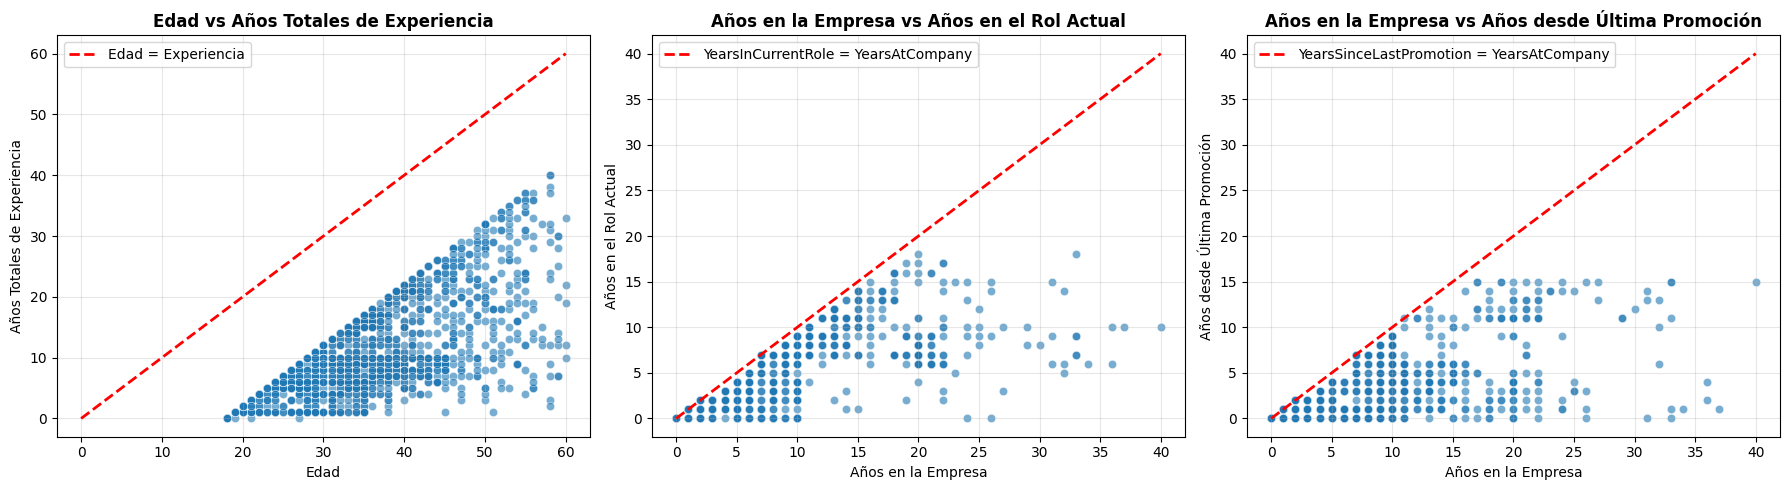

In [31]:

# ============================================
# CREAR FIGURA CON 3 SUBPLOTS
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ============================================
# GRÁFICO 1: Edad vs Años de Experiencia
# ============================================

ax = axes[0]
sns.scatterplot(data=df, x='Age', y='TotalWorkingYears', alpha=0.6, ax=ax)
ax.plot([0, df['Age'].max()], [0, df['Age'].max()], 'r--', 
        label='Edad = Experiencia', linewidth=2)
ax.set_title('Edad vs Años Totales de Experiencia', fontsize=12, fontweight='bold')
ax.set_xlabel('Edad', fontsize=10)
ax.set_ylabel('Años Totales de Experiencia', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

# ============================================
# GRÁFICO 2: Años en Empresa vs Años en Rol
# ============================================

ax = axes[1]
sns.scatterplot(data=df, x='YearsAtCompany', y='YearsInCurrentRole', alpha=0.6, ax=ax)
ax.plot([0, df['YearsAtCompany'].max()], [0, df['YearsAtCompany'].max()], 'r--', 
        label='YearsInCurrentRole = YearsAtCompany', linewidth=2)
ax.set_title('Años en la Empresa vs Años en el Rol Actual', fontsize=12, fontweight='bold')
ax.set_xlabel('Años en la Empresa', fontsize=10)
ax.set_ylabel('Años en el Rol Actual', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

# ============================================
# GRÁFICO 3: Años en Empresa vs Años desde Promoción
# ============================================

ax = axes[2]
sns.scatterplot(data=df, x='YearsAtCompany', y='YearsSinceLastPromotion', alpha=0.6, ax=ax)
ax.plot([0, df['YearsAtCompany'].max()], [0, df['YearsAtCompany'].max()], 'r--', 
        label='YearsSinceLastPromotion = YearsAtCompany', linewidth=2)
ax.set_title('Años en la Empresa vs Años desde Última Promoción', fontsize=12, fontweight='bold')
ax.set_xlabel('Años en la Empresa', fontsize=10)
ax.set_ylabel('Años desde Última Promoción', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

# ============================================
# AJUSTAR Y GUARDAR
# ============================================

plt.tight_layout()

# Guardar
output_path = os.path.join('..', 'outputs', 'figures', 'analisis_consistencia_temporal.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico guardado: {output_path}")

plt.show()